### Import packages and data

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

In [2]:
PROJECT_ROOT = Path("/Users/tildeidunsloth/Desktop/Thesis")
SRL_DIR = PROJECT_ROOT / "data" / "SRL"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

In [3]:
romance_srl = pd.read_csv(SRL_DIR / "romance_srl_cleaned.csv")
lit_fic_srl = pd.read_csv(SRL_DIR / "literary_fiction_srl_cleaned.csv")
sci_fi_srl = pd.read_csv(SRL_DIR / "sci_fi_srl_cleaned.csv")

In [4]:
# combine
df_all = pd.concat([romance_srl, sci_fi_srl, lit_fic_srl], ignore_index=True)

In [5]:
# rename genres
df_all["genre"] = df_all["genre"].replace({
    "romance": "Romance",
    "Literary_fiction": "Literary Fiction",
    "sci_fi": "Science Fiction"
})

In [6]:
# filter out predicates that aren't verbs
non_verbs = ["collar", "ars", "heavier", "knees", "hand closed", "hand covered", "s", "arrival"]

df_all = df_all[~df_all["predicate"].isin(non_verbs)]


In [7]:
# remove predicate_lemma NAs
df_all = df_all.dropna(subset=["predicate_lemma"])

In [8]:
# remove all predicate_lemma = "comm"
df_all = df_all[df_all["predicate_lemma"] != "comm"]

In [9]:
# change predicate_lemma "knitting" to "knit"
df_all.loc[df_all["predicate_lemma"] == "knitting", "predicate_lemma"] = "knit"
df_all.loc[df_all["predicate_lemma"] == "star", "predicate_lemma"] = "stare"
df_all.loc[df_all["predicate_lemma"] == "would", "predicate_lemma"] = "will"
df_all.loc[df_all["predicate_lemma"] == "mistaken", "predicate_lemma"] = "mistake"
df_all.loc[df_all["predicate_lemma"] == "bit", "predicate_lemma"] = "bite"
df_all.loc[df_all["predicate_lemma"] == "offering", "predicate_lemma"] = "offer"
df_all.loc[df_all["predicate_lemma"] == "froze", "predicate_lemma"] = "freeze"

### Subsets with both agent and patient

In [10]:
# filter rows that both have agent and patient (not null)
df_filtered = df_all.dropna(subset=['agent', 'patient'])
df_filtered_agent_female_patient_male = df_filtered[(df_filtered['agent_gender'] == 'female') & (df_filtered['patient_gender'] == 'male')]
df_filtered_agent_male_patient_female = df_filtered[(df_filtered['agent_gender'] == 'male') & (df_filtered['patient_gender'] == 'female')]
df_filtered_agent_male_patient_male = df_filtered[(df_filtered['agent_gender'] == 'male') & (df_filtered['patient_gender'] == 'male')]
df_filtered_agent_female_patient_female = df_filtered[(df_filtered['agent_gender'] == 'female') & (df_filtered['patient_gender'] == 'female')]

In [11]:
# Create copies with labels
ff_pm = df_filtered_agent_female_patient_male.copy()
ff_pm["pairing"] = "Female Agent → Male Patient"

mf_pf = df_filtered_agent_male_patient_female.copy()
mf_pf["pairing"] = "Male Agent → Female Patient"

mm = df_filtered_agent_male_patient_male.copy()
mm["pairing"] = "Male Agent → Male Patient"

ff = df_filtered_agent_female_patient_female.copy()
ff["pairing"] = "Female Agent → Female Patient"

# Combine all subsets
df_combination_plot = pd.concat([ff_pm, mf_pf, mm, ff])

### Plot frequencies for agents and patients

In [12]:
# remove receiver and receiver_gender
df_all = df_all.drop(columns=['receiver', 'receiver_gender'])

In [13]:
gender_cols = ["agent_gender", "patient_gender"]

df_long = df_all.melt(
    id_vars=["genre", "agent_type"],
    value_vars=gender_cols,
    var_name="role",
    value_name="gender"
)

df_long["role"] = df_long["role"].str.replace("_gender", "")
df_long = df_long.dropna(subset=["gender"])

In [14]:
# remove mixed gender
df_long = df_long[df_long['gender'] != 'mixed']

In [15]:
df_counts = (
    df_long
    .groupby(["genre", "role", "gender"])
    .size()
    .reset_index(name="count")
)

df_counts["percentage"] = (
    df_counts
    .groupby(["genre", "role"])["count"]
    .transform(lambda x: 100 * x / x.sum())
)

In [16]:
df_counts_agent_type = (
    df_long
    .groupby(["genre", "role", "gender", "agent_type"])
    .size()
    .reset_index(name="count")
)

df_counts_agent_type["percentage"] = (
    df_counts_agent_type
    .groupby(["genre", "role", "agent_type"])["count"]
    .transform(lambda x: 100 * x / x.sum())
)

In [17]:
baselines = (
    df_counts[df_counts["gender"] == "male"]
    .groupby("genre")
    .apply(lambda x: (x["percentage"] * x["count"]).sum() / x["count"].sum())
    .to_dict()
)

/var/folders/wv/k1c_2q2x52q536wp2_p2kdpm0000gn/T/ipykernel_99651/3953147716.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["percentage"] * x["count"]).sum() / x["count"].sum())


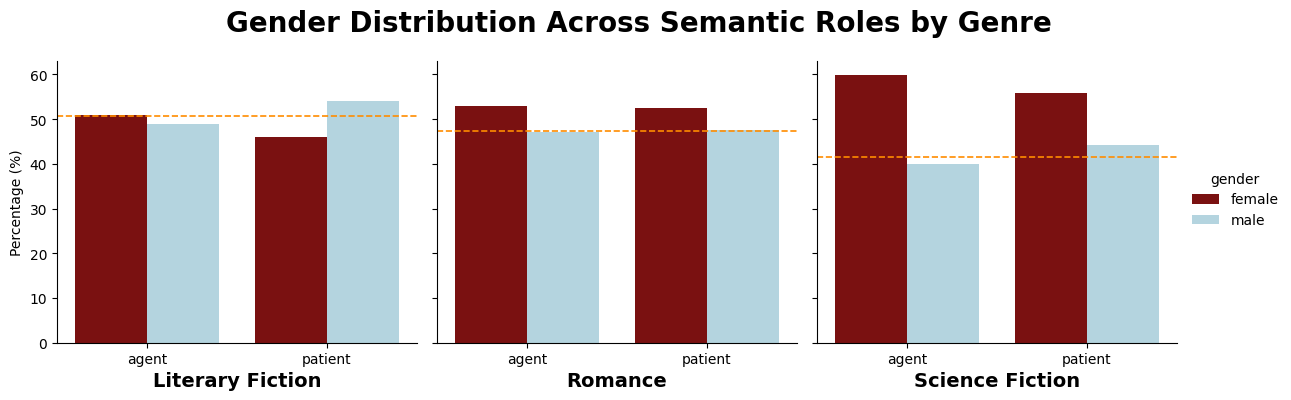

In [19]:
g = sns.catplot(
    data=df_counts,
    x="role",
    y="percentage",
    hue="gender",
    col="genre",
    kind="bar",
    height=4,
    aspect=1,
    palette=["darkred", "lightblue"]
)

# Add baselines
for ax, title in zip(g.axes.flat, g.col_names):
    baseline = baselines.get(title)
    if baseline is not None:
        ax.axhline(
            y=baseline,
            color="darkorange",
            linestyle="--",
            linewidth=1.2
        )

# Remove default titles
g.set_titles("")

# Add titles below each subplot
for ax, col_name in zip(g.axes.flat, g.col_names):
    ax.text(
        0.5, -0.1, col_name,   # x centered, y below axis
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=14,
        fontweight="bold"
    )

g.set_xlabels("")
g.set_ylabels("Percentage (%)")

g.fig.suptitle(
    "Gender Distribution Across Semantic Roles by Genre",
    fontsize=20,
    fontweight="bold"
)

g.fig.subplots_adjust(top=0.85)

plt.savefig(FIGURES_DIR / "Relational_bias/gender_distribution_across_semantic_roles_by_genre.png", dpi=300)
plt.show()

### Check which predicates each gender are associated with

In [24]:
gender_cols = ["agent_gender", "patient_gender"]
role_cols = ["agent", "patient"]

# reshape both role + gender together
df_long_pred = pd.concat([
    df_all.assign(role="agent", entity=df_all["agent"], gender=df_all["agent_gender"]),
    df_all.assign(role="patient", entity=df_all["patient"], gender=df_all["patient_gender"])
])

# keep only relevant columns
df_long_pred = df_long_pred[["genre", "predicate", "predicate_lemma", "role", "gender", "verb_lexname"]]

# drop missing
df_long_pred = df_long_pred.dropna(subset=["gender", "predicate"])

In [25]:
min_count = 10 

df_counts_pred = (
    df_long_pred
    .groupby(["genre", "role", "gender", "predicate_lemma"])
    .size()
    .reset_index(name="count")
)

df_counts_pred["total_predicate"] = (
    df_counts_pred.groupby(["genre", "role", "predicate_lemma"])["count"]
    .transform("sum")
)

df_filtered = df_counts_pred[df_counts_pred["total_predicate"] >= min_count]

# remove gender = mixed
df_filtered = df_filtered[df_filtered["gender"] != "mixed"]

df_filtered["prop"] = (
    df_filtered.groupby(["genre", "role", "predicate_lemma"])["count"]
    .transform(lambda x: x / x.sum())
)

In [26]:
# choose top 10 predicates by proportion for each genre, role, and gender
N = 10

df_top = (
    df_filtered
    .sort_values(
        ["genre", "role", "gender", "prop"],
        ascending=[True, True, True, False]
    )
    .groupby(["genre", "role", "gender"])
    .head(N)
)

In [27]:
df_agents = df_top[df_top["role"] == "agent"]
df_patients = df_top[df_top["role"] == "patient"]

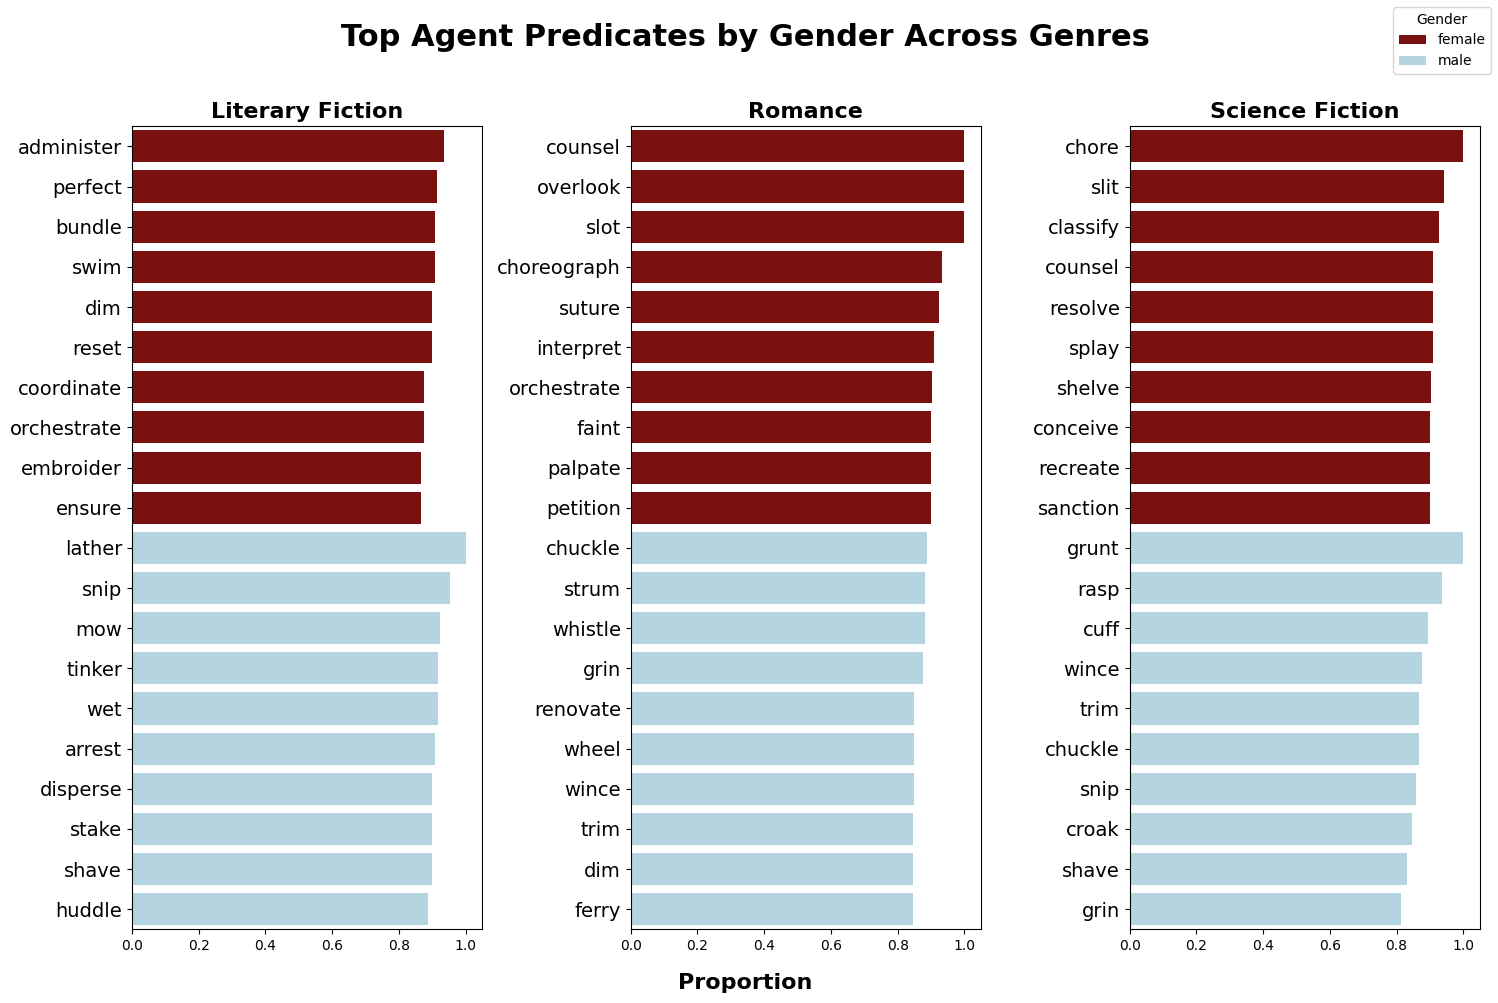

In [31]:
roles = [
    ("Agent", df_agents)
]

genres = df_agents["genre"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(genres),
    figsize=(5 * len(genres), 10),
    sharex=False
)

# Ensure axes is iterable even if only one genre
if len(genres) == 1:
    axes = [axes]

role_name, df_role = roles[0]

for col_idx, genre in enumerate(genres):

    ax = axes[col_idx]

    subdf = df_role[df_role["genre"] == genre]

    sns.barplot(
        data=subdf,
        y="predicate_lemma",
        x="prop",
        hue="gender",
        palette=["darkred", "lightblue"],
        ax=ax
    )

    ax.set_title(genre, fontsize=16, fontweight="bold")
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.tick_params(axis='y', labelsize=14)

    ax.get_legend().remove()

# Global legend
handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Gender",
    loc="upper right"
)

# Global title
fig.suptitle(
    "Top Agent Predicates by Gender Across Genres",
    fontsize=22,
    fontweight="bold"
)

fig.supxlabel(
    "Proportion",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    FIGURES_DIR / "Relational_bias/top_agent_predicates_by_gender.png",
    dpi=300
)

plt.show()

### Gender distribution for verb categories

In [32]:
df_long_pred = df_long_pred[df_long_pred["gender"] != "mixed"]

In [33]:
# remove "verb.weather" from verb_lexname
df_long_pred = df_long_pred[df_long_pred["verb_lexname"] != "verb.weather"]

In [34]:
# Binary encode gender (male = 1, female = 0)
df_long_pred["gender_bin"] = (df_long_pred["gender"] == "male").astype(int)

In [41]:
# only keep agents
df_long_pred_agents = df_long_pred[df_long_pred["role"] == "agent"]

In [44]:
# save to csv
df_long_pred_agents.to_csv(SRL_DIR / "srl_long_format.csv", index=False)

In [45]:
# load plot csv from R
df_plot = pd.read_csv(SRL_DIR / "srl_plot_data.csv")

In [46]:
df_plot["verb_lexname"] = df_plot["verb_lexname"].str.replace("verb.", "", regex=False)

# if stars is NA, replace with empty string
df_plot["stars"] = df_plot["stars"].fillna("")

In [47]:
df_plot_agents = df_plot[df_plot["role"] == "agent"]

genre_colors = {
    "Literary Fiction": "lightblue", 
    "Romance": "lightcoral",          
    "Science Fiction": "lightgreen"             
}

roles = [
    ("Agent", df_plot_agents)

]

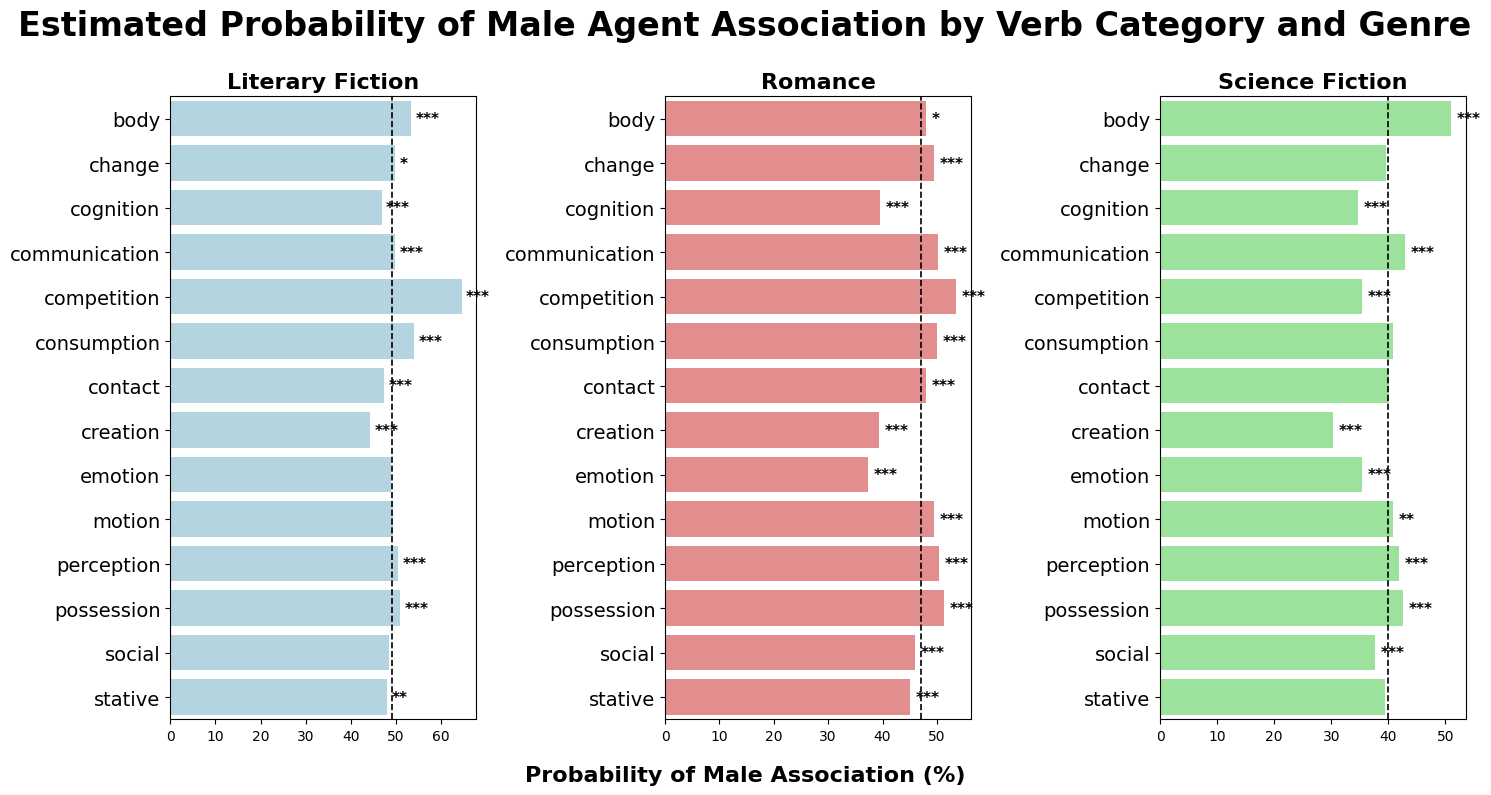

In [48]:
genres = df_plot_agents["genre"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(genres),
    figsize=(5 * len(genres), 8),
    sharex=False
)

# Ensure axes is iterable even if only one genre
if len(genres) == 1:
    axes = [axes]

role_name, df_role = roles[0]

for row_idx, (role_name, df_role) in enumerate(roles):
    for col_idx, genre in enumerate(genres):
        
        ax = axes[col_idx]
        subdf = df_role[df_role["genre"] == genre]
        
        # Get baseline for this genre x role combination
        baseline_val = subdf["p_male_baseline"].iloc[0] * 100

        sns.barplot(
            data=subdf,
            y="verb_lexname",
            x="percent_male",
            hue="genre",
            palette=genre_colors,
            ax=ax
        )

        # Add baseline reference line
        ax.axvline(
            x=baseline_val,
            color="black",
            linestyle="--",
            linewidth=1.2,
            label=f"Baseline ({baseline_val:.0f}%)"
        )

        # Titles
        if row_idx == 0:
            ax.set_title(genre, fontsize=16, fontweight="bold")


        ax.set_ylabel(None)
        ax.set_xlabel(None)
        ax.tick_params(axis='y', labelsize=14)

        # Remove redundant legends
        ax.get_legend().remove()

        # Add stars
        order = [t.get_text() for t in ax.get_yticklabels()]

        for i, verb in enumerate(order):
            row = subdf[subdf["verb_lexname"] == verb].iloc[0]
            star = row["stars"]

            if pd.isna(star) or star == "" or star == "nan":
                continue

            ax.text(
                row["percent_male"] + 1.0,
                i,
                star,
                va="center",
                ha="left",
                fontsize=11,
                fontweight="bold"
            )

# Global title
fig.suptitle(
    "Estimated Probability of Male Agent Association by Verb Category and Genre",
    fontsize=24,
    fontweight="bold"
)

fig.supxlabel(
    "Probability of Male Association (%)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(FIGURES_DIR / "Relational_bias/estimated_probability_of_male_association_by_verb_category_genre_role.png", dpi=300)
plt.show()

### Sentences with gendered agents and patients

In [124]:
# remove "verb.weather" from verb_lexname
df_combination_plot["verb_lexname"] = df_combination_plot["verb_lexname"].str.replace("verb.weather", "", regex=False)

# remove empty verb_lexname
df_combination_plot = df_combination_plot[df_combination_plot["verb_lexname"] != ""]

In [125]:
counts_combination = (
    df_combination_plot
    .groupby(["genre", "pairing", "verb_lexname"])
    .size()
    .reset_index(name="count")
)

counts_combination["percentage"] = (
    counts_combination
    .groupby(["genre", "pairing"])["count"]
    .transform(lambda x: x / x.sum() * 100)
)

In [126]:
pairing_order = [
    "Female Agent → Female Patient",
    "Male Agent → Male Patient",
    "Female Agent → Male Patient",
    "Male Agent → Female Patient",
]

counts_combination["pairing"] = pd.Categorical(
    counts_combination["pairing"],
    categories=pairing_order,
    ordered=True
)

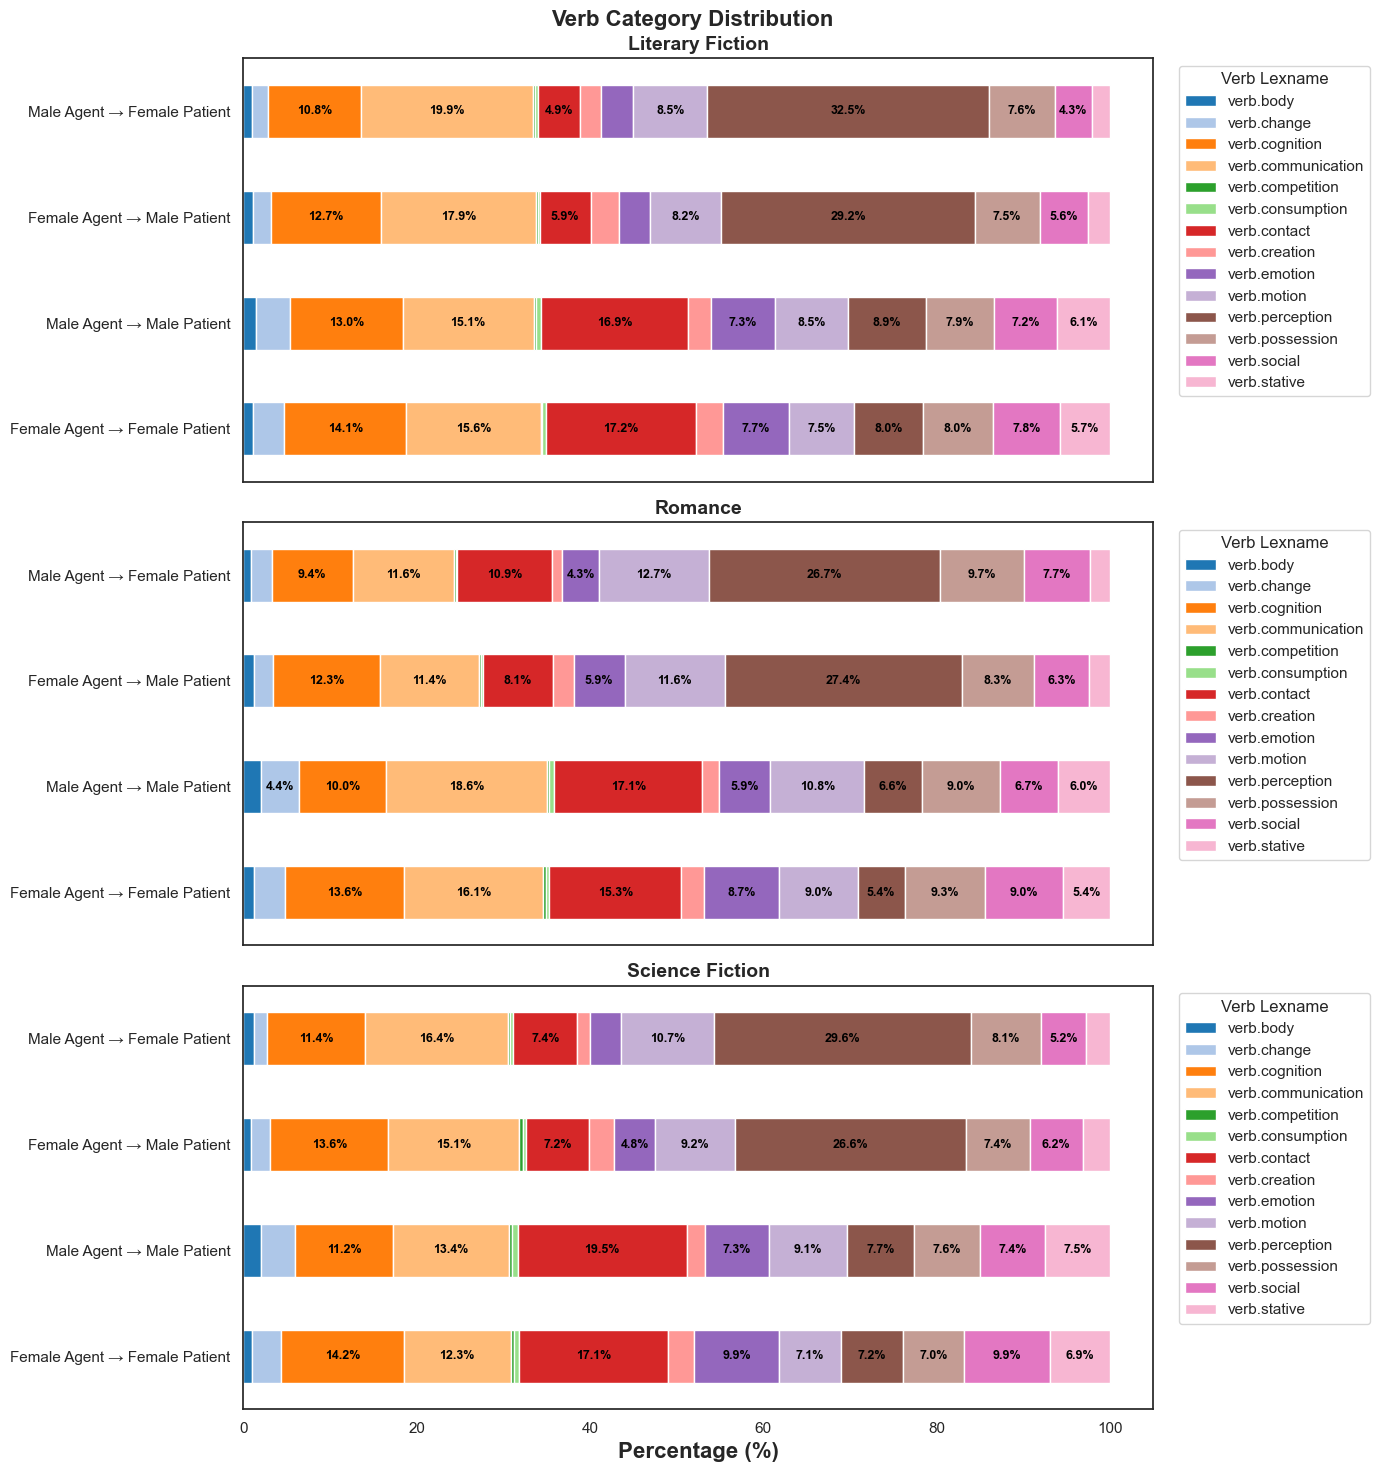

In [169]:
palette = sns.color_palette("tab20")

genres = counts_combination["genre"].unique()

fig, axes = plt.subplots(
    nrows=len(genres),
    figsize=(14, 5 * len(genres)),
    sharex=True
)

if len(genres) == 1:
    axes = [axes]

for ax, genre in zip(axes, genres):

    df_genre = counts_combination[
        counts_combination["genre"] == genre
    ]

    pivot_df = df_genre.pivot(
        index="pairing",
        columns="verb_lexname",
        values="percentage"
    ).fillna(0)

    # Ensure consistent color mapping across plots
    pivot_df = pivot_df[sorted(pivot_df.columns)]

    pivot_df.plot(
        kind="barh",
        stacked=True,
        ax=ax,
        color=palette[:len(pivot_df.columns)]
    )

    # Add percentage labels inside bars
    for i, pairing in enumerate(pivot_df.index):
        cumulative = 0
        for col in pivot_df.columns:
            val = pivot_df.loc[pairing, col]
            if val > 4:
                ax.text(
                    cumulative + val / 2, i,
                    f"{val:.1f}%",
                    ha="center", va="center",
                    fontsize=9, color="black", fontweight="bold"
                )
            cumulative += val

    ax.set_title(
        f"{genre}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Percentage (%)", fontsize=16, fontweight="bold")
    ax.set_ylabel("")

    ax.legend(
        title="Verb Lexname",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
# global title
fig.suptitle("Verb Category Distribution", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

#### Distribution

In [148]:
agg = df_combination_plot.groupby(["genre", "pairing"]).size().reset_index(name="count")
totals = agg.groupby("genre")["count"].transform("sum")
agg["pct_norm"] = agg["count"] / totals * 100

pivot = agg.pivot(index="genre", columns="pairing", values="pct_norm").fillna(0)

col_order = [
    "Female Agent → Female Patient",
    "Female Agent → Male Patient",
    "Male Agent → Female Patient",
    "Male Agent → Male Patient",
]
pivot = pivot[col_order]

In [150]:
colors = ["#E07B87", "#F0B8A0", "#7BA7BC", "#4A708B"]
palette = dict(zip(col_order, colors))

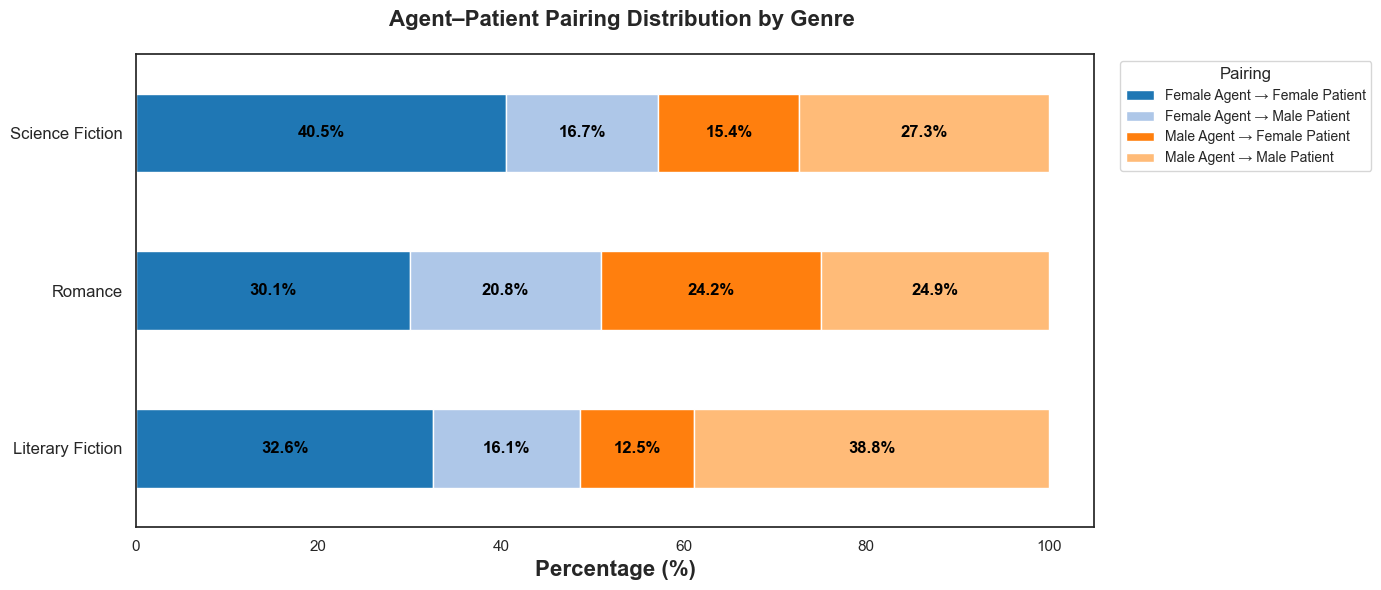

In [163]:
# Pivot
pivot_df = agg.pivot(index="genre", columns="pairing", values="pct_norm") \
              .reindex(columns=col_order).fillna(0)

# Style
palette = sns.color_palette("tab20")
color_map = dict(zip(col_order, palette[:len(col_order)]))

fig, ax = plt.subplots(figsize=(14, 6))

pivot_df.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=[color_map[c] for c in col_order]
)

# Add percentage labels inside bars
for i, genre in enumerate(pivot_df.index):
    cumulative = 0
    for col in col_order:
        val = pivot_df.loc[genre, col]
        if val > 4:  # only label if segment is wide enough
            ax.text(
                cumulative + val / 2, i,
                f"{val:.1f}%",
                ha="center", va="center",
                fontsize=12, color="black", fontweight="bold"
            )
        cumulative += val

ax.set_xlabel("Percentage (%)", fontsize=16, fontweight="bold")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=12)
ax.legend(
    title="Pairing",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10
)

fig.suptitle("Agent–Patient Pairing Distribution by Genre", 
             fontsize=16, fontweight="bold", x=0.45)
plt.tight_layout()
plt.show()